# Band Structure

For molecules, we can write each electronic wavefunction as a simple sum of localized atomic orbitals:
$$
|\Psi_i\rangle=\sum_\mu c_{i\mu}\,|\mu\rangle .
$$
Here, $|\mu\rangle$ represents a basis orbital (usually centered on atoms), and the coefficients $c_{i\mu}$ tell us how much each atomic orbital contributes to the molecular state $i$. This works well because a molecule is a finite object: the orbitals are only needed inside the molecule, and there is no repeating pattern in space.

For periodic systems (crystals, slabs, nanowires), the atomic structure repeats indefinitely, so the wavefunctions must follow the same periodic symmetry. Bloch’s theorem tells us that the electronic states in such systems can be labeled by two quantum numbers: the band index $n$ and the crystal momentum (k-point) $\mathbf{k}$. In SIESTA, the Bloch wavefunction is expanded using localized orbitals repeated over all unit cells:
$$
\psi_{n\mathbf{k}}(\mathbf{r})=
\sum_{\mu,\mathbf{R}}
c_{\mu,n\mathbf{k}}\,
e^{i\mathbf{k}\cdot(\mathbf{R}+\mathbf{d}_\mu)}\,
\phi_\mu(\mathbf{r}-\mathbf{R}-\mathbf{d}_\mu) .
$$
The vector $\mathbf{R}$ shifts the orbital to different unit cells, while $\mathbf{d}_\mu$ gives the orbital’s position *inside* the unit cell. The exponential term $e^{i\mathbf{k}\cdot(\mathbf{R}+\mathbf{d}_\mu)}$ is the Bloch phase factor: it ensures that when we move from one unit cell to another, the wavefunction changes only by a phase, which is exactly the condition required by periodicity. A special point is that SIESTA includes $\mathbf{d}_\mu$ in the phase factor, meaning the phase is taken at the real atomic-orbital position, not just at the lattice vector $\mathbf{R}$.

The energies of these states are written as $\epsilon_n(\mathbf{k})$, showing that the energy depends both on the band $n$ and on the k-point $\mathbf{k}$. If we scan $\mathbf{k}$ across the allowed region of reciprocal space, we obtain the electronic band structure of the material. The allowed $\mathbf{k}$-points lie inside the Brillouin Zone, which is the “primitive cell” of reciprocal space: it is the Wigner–Seitz (Voronoi) cell of the reciprocal lattice, containing all unique k-points needed to describe the periodic system.


In [1]:
!pwd

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/electronic-structure-analysis/MgO


In [2]:
!mkdir -p Practice1

In [3]:
ls

dos.mpr            MgO.POSCAR              O.psf
fatbands.mpr       Mg.psf                  pdos.gplot
images/            o-fatbands-dots.gplot   Practice1/
mg-fatbands.gplot  o-fatbands.gplot        Untitled.ipynb
MgO.fdf            o-fatbands-lines.gplot


In [4]:
!cp Mg.psf O.psf MgO.fdf Practice1/

In [5]:
%cd Practice1

/home/l-rishiraj/siesta-docs/work-files/tutorials/basic/electronic-structure-analysis/MgO/Practice1


/home/l-rishiraj/miniconda3/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
ls

MgO.fdf  Mg.psf  O.psf


In [7]:
!siesta < MgO.fdf > MgO.out

Job completed


In [8]:
ls

0_NORMAL_EXIT                MgO.BASIS_ENTHALPY  MgO.PDOS
BASIS_ENTHALPY               MgO.bib             MgO.PDOS.KP
BASIS_HARRIS_ENTHALPY        MgO.BONDS           MgO.PDOS.xml
CLOCK                        MgO.BONDS_FINAL     MgO.RHO
DeltaRho.grid.nc             MgO.DM              MgO.STRUCT_OUT
fdf.20260124T131129.292.log  MgO.DOS             MgO.XV
FORCE_STRESS                 MgO.DRHO            Mg.psf
INPUT_TMP.03502              MgO.EIG             NON_TRIMMED_KP_LIST
MESSAGES                     MgO.FA              O.ion
Mg.ion                       MgO.fdf             O.ion.nc
Mg.ion.nc                    MgO.fullBZ.WFSX     O.ion.xml
Mg.ion.xml                   MgO.HSX             O.psf
MgO.alloc                    MgO.KP              OUTVARS.yml
MgO.bands                    MgO.ORB_INDX        PARALLEL_DIST
MgO.bands.WFSX               MgO.out             Rho.grid.nc


In [12]:
%%bash

gnubands < MgO.bands > bands.dat

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "bands.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
load "bands.gplot"
EOF


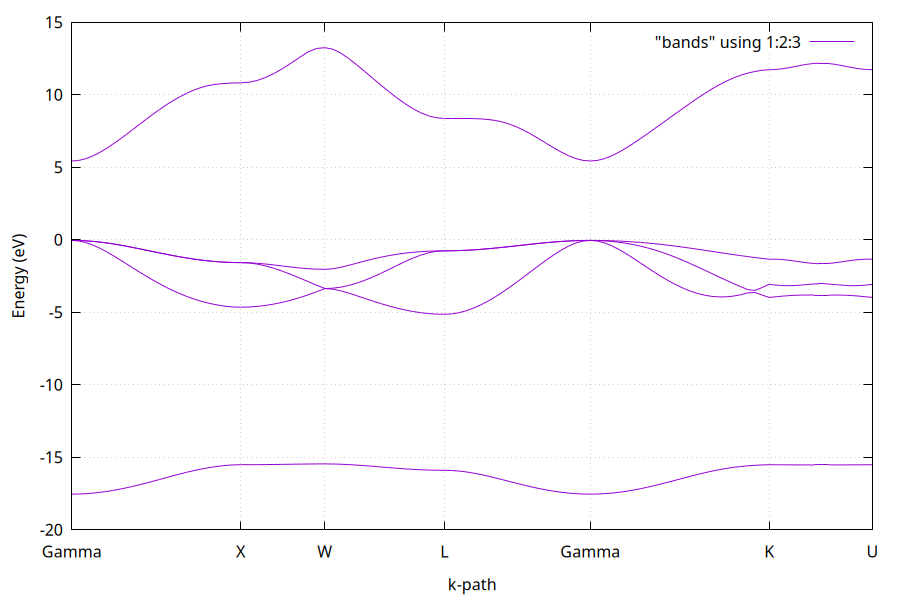

In [13]:
from IPython.display import Image, display
display(Image("bands.png"))


In [10]:
!gnubands -G -o bands -F -b 1 -B 5 MgO.bands

In [11]:
!gnuplot -persist -e "set grid" bands.gplot

## We plotted the first 5 bands — 4 are occupied, why?
 

In the MgO band-structure calculation, we find that 4 bands are occupied because this is determined by the total number of valence electrons in the unit cell. Magnesium contributes 2 valence electrons (from its 3s² configuration) and oxygen contributes 6 valence electrons (from 2s²2p⁴), giving a total of 8 valence electrons per unit cell. Since this is a non–spin-polarized calculation, each band can accommodate 2,**electrons** (one with spin up and one with spin down), so the number of fully occupied bands is 8/4=2.

This is consistent the four band shifts near the Fermi level, so the First four band below the fermi level ,i.e $E_F$ = 0 eV(occupied),**Valence Band** and the fifth band which is above the Fermi level is eventually **empty** , which is considered to be **Conduction Band**.

### Fermi level shifted to 0 eV

In band-structure plots it is common to **shift all energies** so that the **Fermi level** is used as a reference and set to
$$
E_F = 0 \ \text{eV}.
$$
With this choice, all states with energies **below 0 eV** are **occupied (valence bands)**, while states **above 0 eV** are **empty (conduction bands)**. This makes it easy to visually identify the valence and conduction regions and to estimate the band gap. For an insulator like **MgO**, the Fermi level lies inside the **band gap**, so there are no electronic states at $E_F$, and it often appears aligned with the **top of the valence band** in the plotted spectrum.


### What we learn from the MgO band structure

The band structure tells us the most important electronic properties of MgO. From the plot we can identify the **valence band maximum (VBM)** and the **conduction band minimum (CBM)**, and their energy difference gives the **band gap**,
$$
E_g = E_\mathrm{CBM} - E_\mathrm{VBM}.
$$
We can also check whether MgO has a **direct or indirect gap** by seeing if the VBM and CBM occur at the same k-point or at different k-points. Since no band crosses the Fermi level (shifted to $E_F = 0$ eV), the plot clearly shows that MgO behaves as an **insulator**.

In addition, the **shape (dispersion)** of the bands provides insight into electron mobility and bonding. **Flat bands** indicate weak dispersion, meaning the electrons are more localized and have a larger effective mass, which is typical for **ionic compounds** like MgO where electrons are strongly bound to atoms. Finally, by combining band structure results with PDOS or fat-band analysis, we can assign the orbital character (e.g. O-$2p$ for valence and Mg states for conduction), giving a complete physical interpretation of the electronic structure.


------------------------------------------------------------------------------------------------------------------------------------------

# Theoretical Background: Density of States (DOS)

### Density of States (DOS)

The **density of states (DOS)** describes how many electronic states are available for electrons at each energy. In other words, the DOS tells us how the allowed electronic energy levels are distributed in a material. Unlike a band-structure plot, which shows the energy as a function of crystal momentum $\mathbf{k}$, the DOS depends only on energy and is obtained by summing contributions from all $\mathbf{k}$-points in the Brillouin Zone. This makes the DOS especially useful for understanding how many states exist near important energies such as the **Fermi level** $E_F$, which determines whether a material behaves as a metal, semiconductor, or insulator.

Formally, the DOS is defined as
$$
g(\varepsilon)=\sum_{n,\mathbf{k}}\delta\!\left(\varepsilon-\varepsilon_n(\mathbf{k})\right),
$$
where $\varepsilon_n(\mathbf{k})$ are the band energies and $\delta$ is the Dirac delta function. Since the delta function is not practical numerically, the DOS is typically computed by replacing $\delta$ with a smearing/broadening function (for example a Gaussian), so that each discrete eigenvalue contributes a small peak. Peaks in the DOS often correspond to **flat (weakly dispersive) bands**, where many $\mathbf{k}$-points share similar energies, while gaps in the DOS correspond to **band gaps** where no electronic states exist.

The DOS is closely connected to measurable physical properties. For example, a nonzero DOS at the Fermi level $g(E_F)$ indicates metallic behavior, while $g(E_F)=0$ indicates an insulating or semiconducting state. In addition, by projecting the DOS onto atoms or orbitals (PDOS), one can determine which species and orbitals dominate the valence and conduction regions, giving a deeper chemical and physical interpretation of bonding and electronic structure.


In [14]:
%%bash
Eig2DOS -f -e -20 -E 15 -s 0.4 -k MgO.KP  MgO.EIG >| MgO.dos

In [16]:
%%bash

gnuplot
plot "MgO.dos" with lines


In [18]:
%%bash
ls -lh MgO.dos
head MgO.dos
tail MgO.dos



-rw-rw-r-- 1 l-rishiraj l-rishiraj 12K Jan 24 15:21 MgO.dos
# EIG2DOS: Utility for SIESTA to obtain the electronic density of states
#  E. Artacho, Apr 1999, A. Garcia, Apr 2012
#  Nick R. Papior, Feb 2017
# ------------------------------------------
# Eigenvalues calculated from a non-polarized calculation
# Eigenvalues read from MgO.EIG
# Kpoint weights read from MgO.KP
# Using smearing parameter:   0.4000
# Using 200 points in the energy range
# Selected bands: 1 to: 18
     13.417085      0.803315      0.803315      1.606630
     13.592965      0.874959      0.874959      1.749917
     13.768844      0.810879      0.810879      1.621758
     13.944724      0.697625      0.697625      1.395249
     14.120603      0.606753      0.606753      1.213506
     14.296482      0.546750      0.546750      1.093500
     14.472362      0.474979      0.474979      0.949959
     14.648241      0.359201      0.359201      0.718402
     14.824121      0.221118      0.221118      0.442236
     15.0

In [21]:
%%bash

gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "dos.png"

set xlabel "Energy (eV)"
set ylabel "DOS (states/eV)"
set grid
set key off

plot "MgO.dos" using 1:4 with lines lw 2
EOF


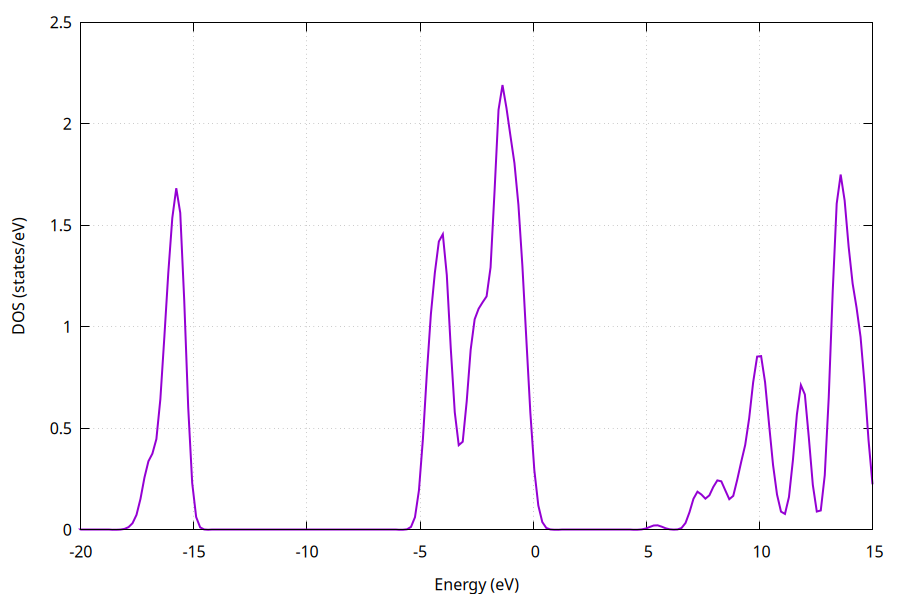

In [22]:
from IPython.display import Image, display
display(Image("dos.png"))


###  What we learn from the DOS of MgO

From the DOS (density of states) plot we see that MgO has a clear region around the Fermi level where the DOS is essentially zero, meaning there are no available electronic states at those energies. This indicates the presence of a **band gap**, confirming that MgO behaves as an **insulator (wide band-gap material)** rather than a metal. The energy difference between the top of the valence states and the bottom of the conduction states provides an estimate of the band gap size. In addition, the sharp peaks in the DOS show that many states are concentrated at specific energies, which is typically associated with relatively flat bands and more localized electronic states, consistent with the mostly ionic nature of MgO.


------------------------------------------------------------------------------------------------------------------------------------------

# Theoretical Summary: Projected Density of States (pDOS)

The **projected density of states (pDOS)** is an extension of the total density of states (DOS) that provides information about the **atomic and orbital origin** of the electronic states in a material. While the total DOS only tells how many states exist at a given energy, the pDOS decomposes this quantity into contributions from selected atoms, species, or orbitals (such as $s$, $p$, or $d$ states). This makes pDOS very useful for understanding chemical bonding, hybridization, and which atoms dominate the valence and conduction bands.

Formally, the total DOS can be written as
$$
g(E)=\sum_{n,\mathbf{k}} \delta\!\left(E-\varepsilon_n(\mathbf{k})\right),
$$
where $\varepsilon_n(\mathbf{k})$ are the band energies. In the pDOS, each state is weighted by its projection onto a chosen set of localized basis functions $\{|\mu\rangle\}$, giving
$$
g_\mu(E)=\sum_{n,\mathbf{k}} \left| \langle \mu|\psi_{n\mathbf{k}}\rangle \right|^2 \, \delta\!\left(E-\varepsilon_n(\mathbf{k})\right).
$$
In practical calculations the delta function is replaced by a small broadening (smearing), producing smooth curves. Peaks in the pDOS indicate energies where many states with a strong contribution from the selected atom/orbital are present, while regions with nearly zero pDOS indicate a lack of states for that projection.

By comparing pDOS from different atoms or orbitals, we can identify which species form the **valence band maximum (VBM)** and the **conduction band minimum (CBM)**, analyze the ionic or covalent nature of bonding, and interpret electronic and optical behavior. For example, in an ionic material such as MgO, the valence band is typically dominated by O-$2p$ states, while the conduction band has mainly Mg character. 


In [23]:
!head MgO.PDOS


<pdos>
<nspin>1</nspin>
<norbitals>18</norbitals>
<fermi_energy units="eV"> -0.840945725E+01</fermi_energy>
<energy_values units="eV">
 -0.260000000E+02
 -0.259398798E+02
 -0.258797595E+02
 -0.258196393E+02
 -0.257595190E+02


In [25]:
%%bash
cat > dos.mpr << 'EOF'
MgO
DOS
Mg-orbitals
Mg
O-orbitals
O
EOF


In [26]:
%%bash
mprop -n 500 -b 1 -B 5 -s 0.4 dos


Reading wave-function file (WFSX).
Energy units are eV
Reading wf file: MgO.fullBZ.WFSX
 NSPIN BLOCKS:            1
Minimum/Maximum number of wfs per k-point:     5    5
Min_eigval, max_eigval on WFS file:     -25.9504      3.5584
Min_eigval, max_eigval in band set :     -25.9504      3.5584
Implicit band set used: (min, max_min, max_max):   1   5   5
Minimum and maximum eigenvalues (based on file data and band selection):     -25.9504      3.5584
Minimum and maximum eigenvalues to be processed:     -25.9504      3.5584
Plotting range adequate for eigenvalue range selected:     -27.1504      4.7584
Using smearing parameter:   0.400
Using    500 points in energy range
 MgO.HSXFermi energy:   -3.71677 (depends on smearing)
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Total number of curves processed:            2
Writing files: dos.stt ...
Curve    Mg-orbitals  Base orbitals and interactions:      5      

In [27]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 900,600
set output "pdos_MgO.png"
set xlabel "Energy (eV)"
set ylabel "PDOS (states/eV)"
set grid
set key top right

plot "dos.O-orbitals.pdos"  u 1:4 w l lw 2 title "O-orbitals", \
     "dos.Mg-orbitals.pdos" u 1:4 w l lw 2 title "Mg-orbitals"
EOF


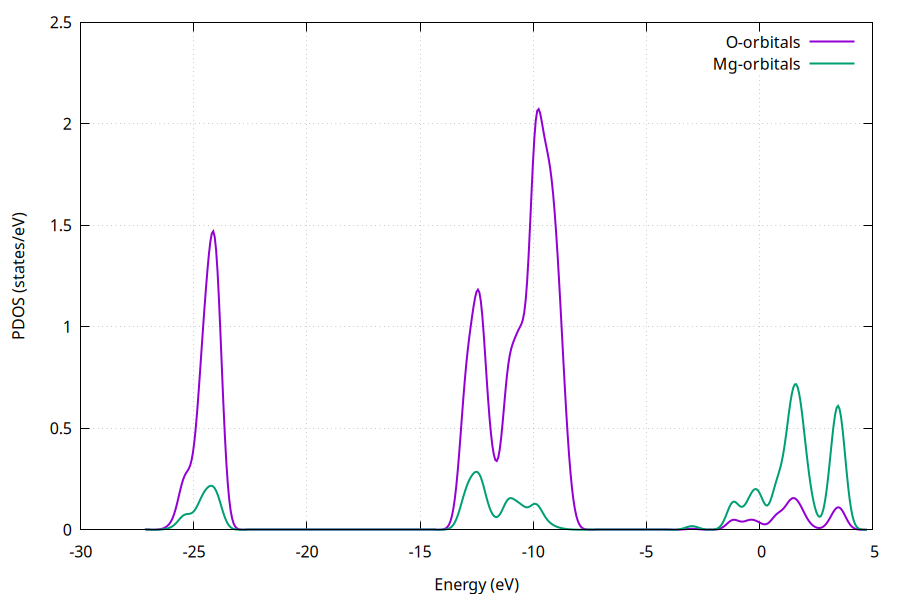

In [28]:
from IPython.display import Image, display
display(Image("pdos_MgO.png"))


### pDOS: Mg vs O

The projected density of states (pDOS) plot separates the electronic states of MgO into contributions from magnesium and oxygen. From the graph, the occupied region below the Fermi level is dominated by the O-orbitals, showing that the valence band mainly has oxygen character (typically O–2p states). In contrast, the unoccupied region above the Fermi level shows a larger contribution from Mg-orbitals, indicating that the conduction band is mainly formed by magnesium states (Mg–s/p). The presence of an energy range around the Fermi level where the pDOS is nearly zero corresponds to the band gap, confirming that MgO is an insulating material. Overall, the clear separation between O-dominated valence states and Mg-dominated conduction states is consistent with the strongly ionic bonding nature of MgO.


------------------------------------------------------------------------------------------------------------------------------------------

## Theoretical Background: Fat Bands (Orbital-Projected Band Structure)

A normal band-structure plot shows the electronic eigenvalues $\varepsilon_n(\mathbf{k})$ as a function of the wavevector $\mathbf{k}$ along a chosen path of high-symmetry points in the Brillouin zone. However, a standard band plot does not tell us *which atoms or orbitals* are responsible for each band.

**Fat bands** (also called *orbital-projected band structures*) solve this by adding information about the **orbital character** of the eigenstates. In practice, each Bloch wavefunction $\psi_{n\mathbf{k}}$ is projected onto a chosen set of localized orbitals $\{|\mu\rangle\}$ (for example, orbitals belonging to a given atom or a given angular momentum channel). The “fatness” (thickness/weight) of each band at a given $\mathbf{k}$ is proportional to the projection weight:

$$
w_{\mu}(n,\mathbf{k}) = \left| \langle \mu \,|\, \psi_{n\mathbf{k}} \rangle \right|^2 .
$$

If $w_{\mu}(n,\mathbf{k})$ is large, the band appears thick at that point, meaning the state has strong contribution from that chosen orbital group. If the weight is small, the band appears thin. Therefore, fat bands allow us to directly see where in k-space the electronic states have mostly Mg character, O character, $s$ character, $p$ character, etc. This is extremely useful for interpreting bonding, band edges (VBM/CBM), hybridization, and charge-transfer effects.


In [60]:
ls

0_NORMAL_EXIT                Mg.ion.nc           MgO.KP
bands                        Mg.ion.xml          MgO.ORB_INDX
bands.dat                    MgO.ados            MgO.out
bands.gplot                  MgO.alldos          MgO.PDOS
bands.png                    MgO.alloc           MgO.PDOS.KP
BASIS_ENTHALPY               MgO.bands           MgO.PDOS.xml
BASIS_HARRIS_ENTHALPY        MgO.bands.WFSX      MgOprop.mpr
CLOCK                        MgO.BASIS_ENTHALPY  MgO.RHO
DeltaRho.grid.nc             MgO.bib             MgO.STRUCT_OUT
dos.Mg-orbitals.pdos         MgO.BONDS           MgO.WFSX@
dos.mpr                      MgO.BONDS_FINAL     MgO.XV
dos.O-orbitals.pdos          MgO.DM              Mg.psf
dos.png                      MgO.dos             NON_TRIMMED_KP_LIST
dos.stt                      MgO.DOS             O.ion
fdf.20260124T131129.292.log  MgO.DRHO            O.ion.nc
fdf.20260124T162604.391.log  MgO.EIG             O.ion.xml
FORCE_STRESS                 MgO.FA              O

In [61]:
%%bash
cat > fatbands.mpr << 'EOF'
MgO
DOS
Mg-orbitals
Mg
O-orbitals
O
EOF


In [62]:
%%bash
ln -sf MgO.bands.WFSX MgO.WFSX


In [63]:
%%bash
fat fatbands


Reading wf file: MgO.bands.WFSX
 Minimum/Maximum number of wfs per k-point:     5    5
Min_eigval, max_eigval on WFS file:     -25.9504      4.8391
Min_eigval, max_eigval in band set :     -25.9504      4.8391
Band set used: (min, max):   1   5
 MgO.HSX Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Total number of curves processed:            2
Writing files: fatbands.stt ...
Fatband coeffs set:    Mg-orbitals  Base orbitals and interactions:      5         3087
Fatband coeffs set:    O-orbitals  Base orbitals and interactions:     13         2671


In [64]:
!ls fatbands*


fatbands.info		     fatbands.mpr
fatbands.Mg-orbitals.EIGFAT  fatbands.O-orbitals.EIGFAT


In [65]:
!ls -lh *.EIGFAT


-rw-rw-r-- 1 l-rishiraj l-rishiraj 19K Jan 24 16:49 fatbands.Mg-orbitals.EIGFAT
-rw-rw-r-- 1 l-rishiraj l-rishiraj 19K Jan 24 16:49 fatbands.O-orbitals.EIGFAT


In [66]:
%%bash
eigfat2plot fatbands.Mg-orbitals.EIGFAT
eigfat2plot fatbands.O-orbitals.EIGFAT


 # # MgO min_band, max_band:     1    5
 # nband, nspin, nk:           5           1         121
 # min_band, max_band:            1           5
      0.000000    -25.950399      0.262540  1
      0.032440    -25.943300      0.262050  1
      0.064880    -25.922199      0.260600  1
      0.097310    -25.887199      0.258190  1
      0.129750    -25.838699      0.254800  1
      0.162190    -25.777399      0.250440  1
      0.194630    -25.703800      0.245110  1
      0.227070    -25.618999      0.238800  1
      0.259510    -25.523800      0.231480  1
      0.291940    -25.419600      0.223130  1
      0.324380    -25.307600      0.213650  1
      0.356820    -25.189400      0.202930  1
      0.389260    -25.066500      0.190810  1
      0.421700    -24.940599      0.177200  1
      0.454140    -24.813601      0.162300  1
      0.486570    -24.687401      0.147240  1
      0.519010    -24.564301      0.134680  1
      0.551450    -24.446800      0.127980  1
      0.583890    -24.33750

In [70]:
%%bash
eigfat2plot fatbands.O-orbitals.EIGFAT  > fatbands.O-orbitals.dat
eigfat2plot fatbands.Mg-orbitals.EIGFAT > fatbands.Mg-orbitals.dat


In [71]:
!ls fatbands*


fatbands.info		     fatbands.mpr		 fatbands_O.png
fatbands.Mg-orbitals.dat     fatbands.O-orbitals.dat
fatbands.Mg-orbitals.EIGFAT  fatbands.O-orbitals.EIGFAT


In [72]:
%%bash
gnubands < MgO.bands > bands.dat


In [99]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,650
set output "fatbands_O_colour.png"

set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
unset key

set datafile commentschars "#"
set yrange [-26:6]

set palette rgb 33,13,10
set cblabel "O weight"
set cbrange [0:*]

plot "fatbands.O-orbitals.dat" using 1:2:(column(3)) with lines lc palette z lw 2
EOF


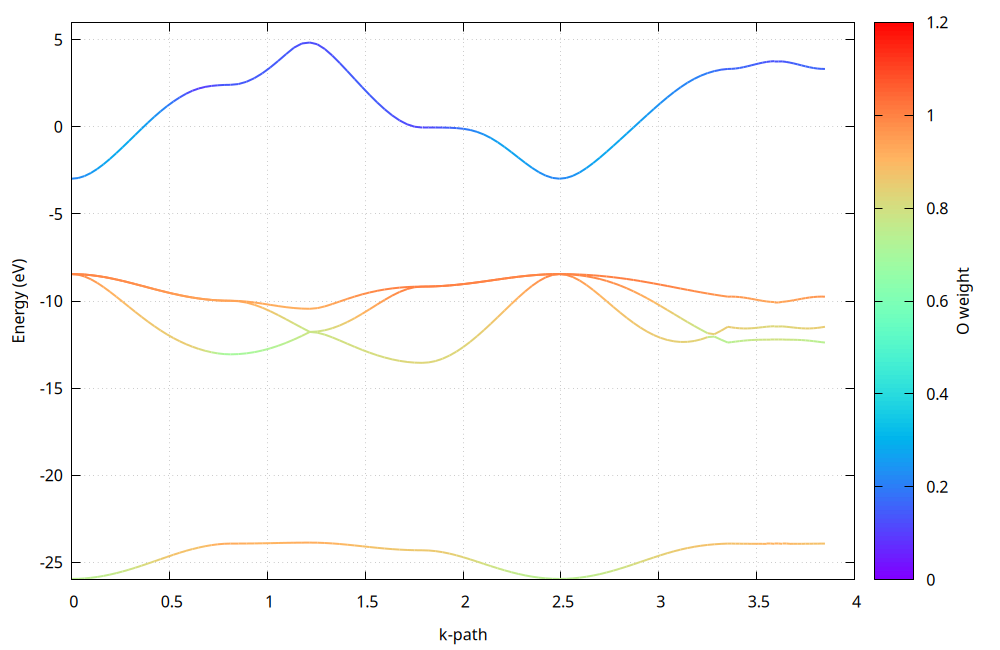

In [100]:
from IPython.display import Image, display
display(Image("fatbands_O_colour.png"))


### Summary of the Oxygen-fatband plot (MgO)

This fatband plot shows the band structure of MgO, where the color (and intensity) represents the **Oxygen orbital weight** in each electronic band. The bands that appear in warm colors (yellow–red) have a **strong O contribution**, while bands in cool colors (blue–purple) have **little O character**. From the figure, the **highest occupied bands (valence band region)** show a strong oxygen weight, meaning the valence band is mainly formed by **O states (mostly O–2p)**. In contrast, the **conduction band region** shows much weaker oxygen character, suggesting that the conduction bands are mainly dominated by **Mg states**. The plot therefore supports the ionic bonding picture of MgO, where electronic states below the band gap are largely oxygen-like, while the states above the gap are more magnesium-like.


In [96]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,650
set output "fatbands_O.png"

set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
unset key

set datafile commentschars "#"
set yrange [-26:6]

set palette rgb 33,13,10
set cblabel "O weight"
set cbrange [0:*]

plot "fatbands.O-orbitals.dat" using 1:2:(3*column(3)) with points pt 6 ps variable
EOF


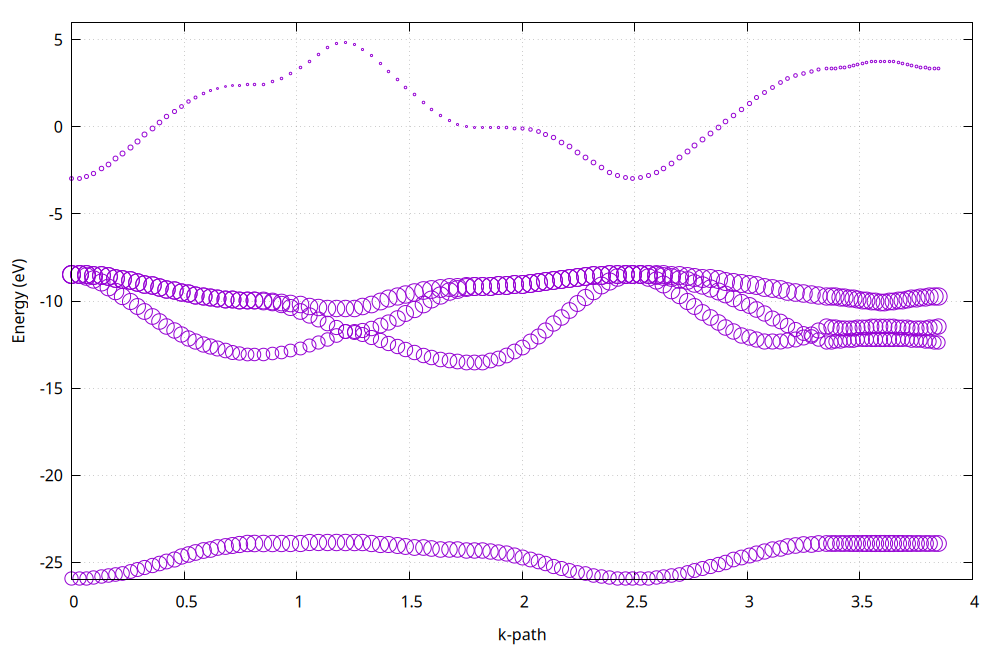

In [97]:
from IPython.display import Image, display
display(Image("fatbands_O.png"))


## Plotting the Magnesium fatband 

In [94]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,650
set output "fatbands_Mg.png"

set xlabel "k-path"
set ylabel "Energy (eV)"
set grid
unset key

set datafile commentschars "#"
set yrange [-30:6]

set palette rgb 33,13,10
set cblabel "Mg-weight"
set cbrange [0:*]

plot "fatbands.Mg-orbitals.dat" using 1:2:(column(3)) with lines lc palette z lw 2
EOF


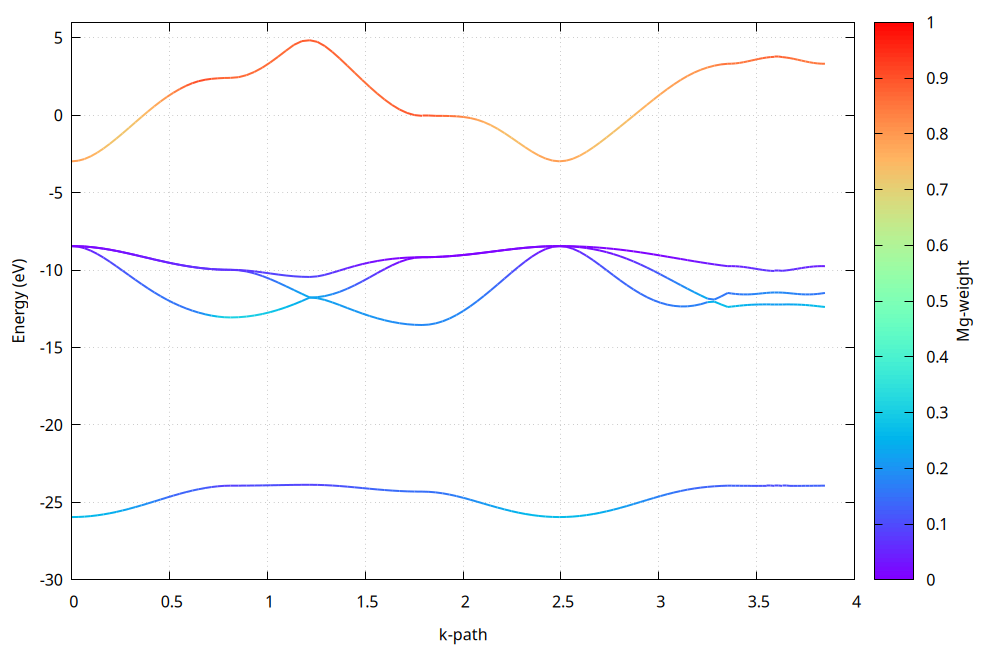

In [95]:
from IPython.display import Image, display
display(Image("fatbands_Mg.png"))


 ### Editing the mpr.file new Oxygen valence orbital 2s and 2p

In [121]:
%%bash

cat > fatbands.mpr << 'EOF'
MgO
DOS
Mg-orbitals
Mg
O-orbitals
O
O-2s-orbitals
O_2s
O-2p-orbitals
O_2p
EOF


In [106]:
%%bash
ln -sf MgO.bands.WFSX MgO.WFSX
fat fatbands


Reading wf file: MgO.bands.WFSX
 Minimum/Maximum number of wfs per k-point:     5    5
Min_eigval, max_eigval on WFS file:     -25.9504      4.8391
Min_eigval, max_eigval in band set :     -25.9504      4.8391
Band set used: (min, max):   1   5
 MgO.HSX Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Size of set_mask:           18
 Total number of curves processed:            4
Writing files: fatbands.stt ...
Fatband coeffs set:    Mg-orbitals  Base orbitals and interactions:      5         3087
Fatband coeffs set:    O-orbitals  Base orbitals and interactions:     13         2671
Fatband coeffs set:    O-2s-orbitals  Base orbitals and interactions:      2          476
Fatband coeffs set:    O-2p-orbitals  Base orbitals and interactions:      6         1186


In [107]:
!ls fatbands*.EIGFAT


fatbands.Mg-orbitals.EIGFAT    fatbands.O-2s-orbitals.EIGFAT
fatbands.O-2p-orbitals.EIGFAT  fatbands.O-orbitals.EIGFAT


In [108]:
%%bash
eigfat2plot fatbands.O-2s-orbitals.EIGFAT > fatbands.O-2s-orbitals.dat
eigfat2plot fatbands.O-2p-orbitals.EIGFAT > fatbands.O-2p-orbitals.dat


In [118]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,650
set output "fatbands_O_2s.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set title "Fatband of O-2s"
set grid
unset key
set datafile commentschars "#"
set yrange [-26:6]
set palette rgb 33,13,10
set cblabel "O-2s weight"
set cbrange [0:*]
plot "fatbands.O-2s-orbitals.dat" using 1:2:(column(3)) with lines lc palette z lw 2
EOF


In [119]:
%%bash
gnuplot << 'EOF'
set terminal pngcairo size 1000,650
set output "fatbands_O_2p.png"
set xlabel "k-path"
set ylabel "Energy (eV)"
set title  "Fatband of O-2p"
set grid
unset key
set datafile commentschars "#"
set yrange [-26:6]
set palette rgb 33,13,10
set cblabel "O-2p weight"
set cbrange [0:*]
plot "fatbands.O-2p-orbitals.dat" using 1:2:(column(3)) with lines lc palette z lw 2
EOF


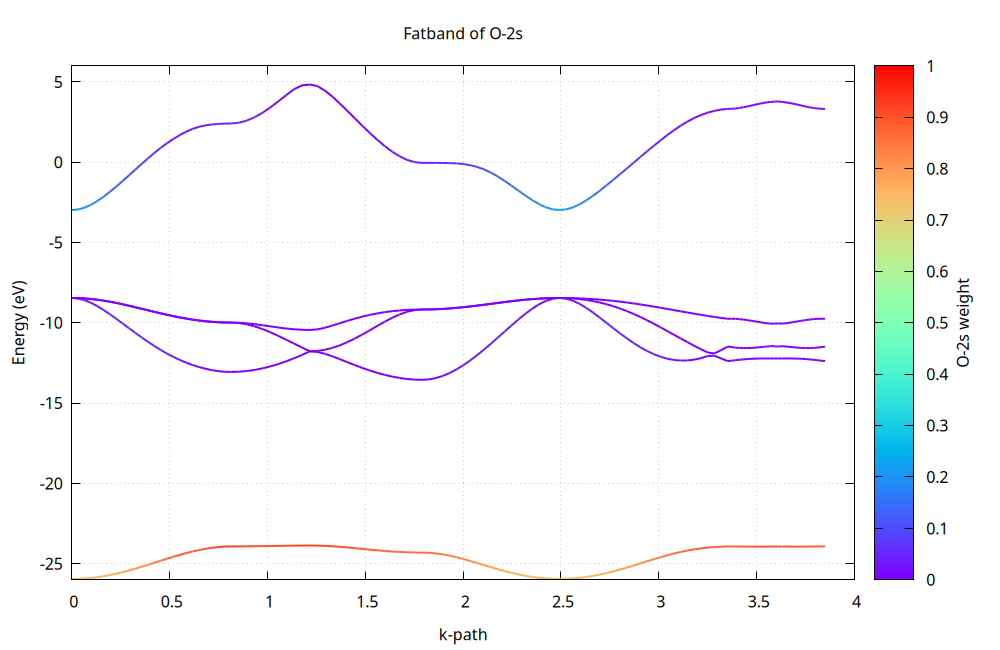

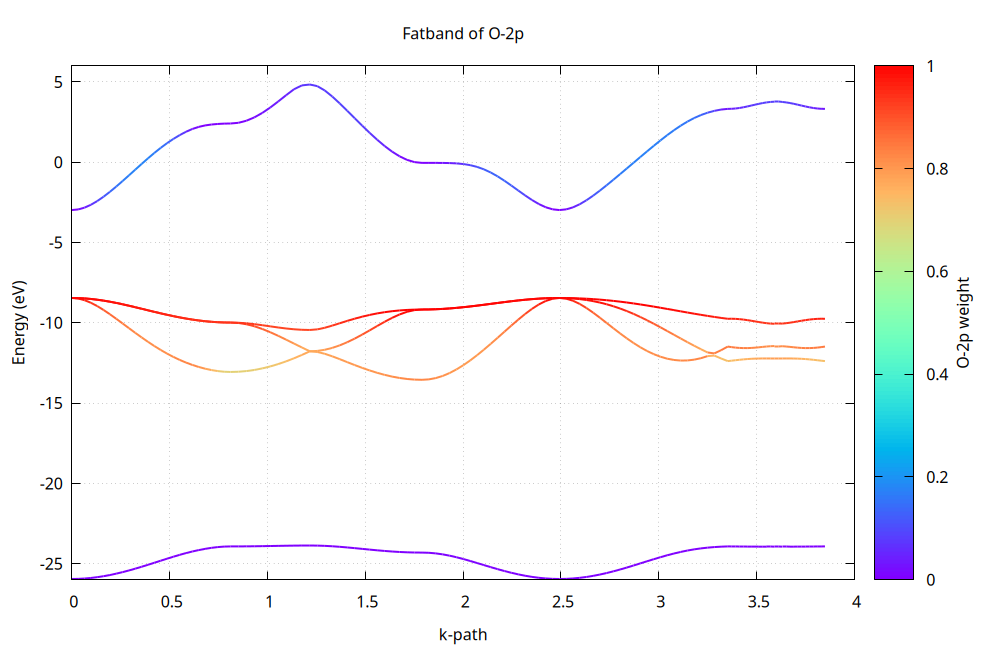

In [120]:
from IPython.display import Image, display
display(Image("fatbands_O_2s.png"))
display(Image("fatbands_O_2p.png"))


###  What we learn from the O-2s and O-2p fatband plots (MgO)

From these two fatband plots we can clearly separate the **orbital origin of the Oxygen-derived states** in MgO. The **O-2s fatband** shows strong weight mainly in the **deep, low-energy band around ~ −25 eV**, meaning the O-2s electrons form **core-like/strongly bound states** and do not contribute much near the valence band edge. In contrast, the **O-2p fatband** shows strong weight in the **upper valence-band region (roughly between −14 eV and −9 eV)**, indicating that the **top of the valence bands is dominated by O-2p character**. This confirms the typical picture of MgO as an ionic insulator: **the valence band is mainly oxygen p-states**, while the conduction bands have much weaker oxygen contribution (more Mg-like), which helps us understand bonding, band-edge composition (VBM/CBM), and the electronic structure responsible for optical and transport properties.
